# Практическая работа 3.1: EDA | Heart Failure Prediction

Цель: выполнить чистый и воспроизводимый разведочный анализ данных для последующего обучения классификатора.


## 1. Импорты и конфигурация

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub

DATASET_HANDLE = "fedesoriano/heart-failure-prediction"
DATASET_FILE = "heart.csv"

TARGET_COL = "HeartDisease"

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 120)


## 2. Описание данных

**Что это за данные:**
- `heart.csv` содержит клинические и инструментальные показатели пациентов.
- Цель: предсказать наличие заболевания сердца (`HeartDisease`).
- Размер: `918` наблюдений, `11` признаков + `1` целевая переменная.

**Источник:**
- Kaggle: `fedesoriano/heart-failure-prediction`.
- Подготовленный набор для задач бинарной классификации сердечно-сосудистого риска.

**Колонки:**
- `Age` — возраст пациента.
- `Sex` — пол (`M`, `F`).
- `ChestPainType` — тип боли в груди (`ATA`, `NAP`, `ASY`, `TA`).
- `RestingBP` — артериальное давление в покое.
- `Cholesterol` — уровень холестерина.
- `FastingBS` — признак повышенного сахара натощак (`1` если > 120 mg/dl, иначе `0`).
- `RestingECG` — результаты ЭКГ в покое.
- `MaxHR` — максимальная частота сердечных сокращений.
- `ExerciseAngina` — стенокардия, вызванная нагрузкой (`Y`/`N`).
- `Oldpeak` — депрессия сегмента ST относительно покоя.
- `ST_Slope` — наклон сегмента ST при нагрузке.
- `HeartDisease` — целевая переменная (`1` — заболевание есть, `0` — нет).


## 3. Загрузка датасета

In [2]:
def load_dataset(
    data_dir: Path,
    dataset_handle: str = DATASET_HANDLE,
    dataset_file: str = DATASET_FILE,
    sep: str = ",",
) -> pd.DataFrame:
    """Загружает датасет Heart Failure Prediction и возвращает его как DataFrame.

    Parameters
    ----------
    data_dir : Path
        Каталог, в который скачиваются файлы датасета.
    dataset_handle : str, default=DATASET_HANDLE
        Идентификатор датасета в Kaggle (`owner/dataset-name`).
    dataset_file : str, default=DATASET_FILE
        Имя CSV-файла, который необходимо прочитать после загрузки.
    sep : str, default="," 
        Разделитель столбцов в исходном CSV-файле.

    Returns
    -------
    pd.DataFrame
        Загруженный датасет в табличном формате.
    """
    kagglehub.dataset_download(
        dataset_handle,
        output_dir=str(data_dir),
    )
    dataset_path = data_dir / dataset_file
    return pd.read_csv(dataset_path, sep=sep)


In [3]:
DATA_DIR = Path(".data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
df = load_dataset(DATA_DIR)
df.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 4. Базовая структура данных

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [5]:
def get_feature_groups(df: pd.DataFrame, target_col: str = TARGET_COL) -> tuple[list[str], list[str]]:
    """Разделяет признаки на числовые и категориальные.

    Parameters
    ----------
    df : pd.DataFrame
        Исходный датасет с признаками и целевой переменной.
    target_col : str, default=TARGET_COL
        Название целевой переменной, исключаемой из списка признаков.

    Returns
    -------
    tuple[list[str], list[str]]
        Кортеж из двух списков: (`numeric_cols`, `categorical_cols`).
    """
    feature_cols = [col for col in df.columns if col != target_col]
    numeric_cols = df[feature_cols].select_dtypes(include=np.number).columns.tolist()
    categorical_cols = [col for col in feature_cols if col not in numeric_cols]
    return numeric_cols, categorical_cols


In [6]:
numeric_cols, categorical_cols = get_feature_groups(df)

feature_groups_df = pd.DataFrame(
    [
        {
            "Группа признаков": "Числовые",
            "Количество": len(numeric_cols),
            "Состав": ", ".join(numeric_cols),
        },
        {
            "Группа признаков": "Категориальные",
            "Количество": len(categorical_cols),
            "Состав": ", ".join(categorical_cols),
        },
    ]
)

display(feature_groups_df)


,Группа признаков,Количество,Состав
0,Числовые,6,"Age, RestingBP, Cholesterol, FastingBS, MaxHR,..."
1,Категориальные,5,"Sex, ChestPainType, RestingECG, ExerciseAngina..."


In [7]:
def summarize_dataset(df: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    """Формирует сводную таблицу структуры датасета и число дубликатов.

    Parameters
    ----------
    df : pd.DataFrame
        Исходный датасет для первичного анализа качества данных.

    Returns
    -------
    tuple[pd.DataFrame, int]
        Сводная таблица по столбцам (`dtype`, `missing`, `nunique`) и
        количество полных дубликатов строк.
    """
    summary = pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "missing": df.isna().sum(),
            "nunique": df.nunique(dropna=False),
        }
    ).sort_values(["nunique"], ascending=[False])
    duplicates = int(df.duplicated().sum())
    return summary, duplicates


In [8]:
summary_table, duplicate_count = summarize_dataset(df)

print(f"Количество полных дубликатов: {duplicate_count}")
display(summary_table)


Количество полных дубликатов: 0


,dtype,missing,nunique
Cholesterol,int64,0,222
MaxHR,int64,0,119
RestingBP,int64,0,67
Oldpeak,float64,0,53
Age,int64,0,50
ChestPainType,str,0,4
RestingECG,str,0,3
ST_Slope,str,0,3
Sex,str,0,2
FastingBS,int64,0,2


Поскольку в целочисленной переменной `FastingBS` всего 2 различных класса, то стоит определить ее как категориальную со строковым значением.


In [9]:
df["FastingBS"] = df["FastingBS"].map({0: "Yes", 1: "No"}).astype("str")


In [10]:
numeric_cols, categorical_cols = get_feature_groups(df)


## 5. Зависимости в данных

## 5.1. Target balance

In [11]:
def plot_target_balance(df: pd.DataFrame, target_col: str = TARGET_COL) -> None:
    """Строит графики распределения целевой переменной.

    Parameters
    ----------
    df : pd.DataFrame
        Датасет, содержащий целевой признак.
    target_col : str, default=TARGET_COL
        Название целевой переменной бинарной классификации.

    Returns
    -------
    None
        Функция отображает графики и не возвращает значение.
    """
    target_distribution = (
        df[target_col]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis(target_col)
        .reset_index(name="count")
    )
    target_distribution["share_%"] = (target_distribution["count"] / len(df) * 100).round(2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.countplot(data=df, x=target_col, order=target_distribution[target_col], ax=axes[0])
    axes[0].set_title("Target balance: распределение классов")
    axes[0].set_xlabel("Класс HeartDisease")
    axes[0].set_ylabel("Количество")

    axes[1].pie(
        target_distribution["count"],
        labels=target_distribution[target_col],
        autopct="%1.1f%%",
        startangle=90,
    )
    axes[1].set_title("Target balance: доли классов")

    plt.tight_layout()
    plt.show()


### Обзор target balance

График распределения целевой переменной `HeartDisease`, представленный в виде столбчатой диаграммы и круговой структуры долей классов.

График показывает фактическое соотношение классов `1` и `0`, то есть наличие или отсутствие дисбаланса в постановке бинарной классификации.

График необходим, потому что баланс классов напрямую влияет на интерпретацию метрик качества и на корректность сравнительной оценки моделей.


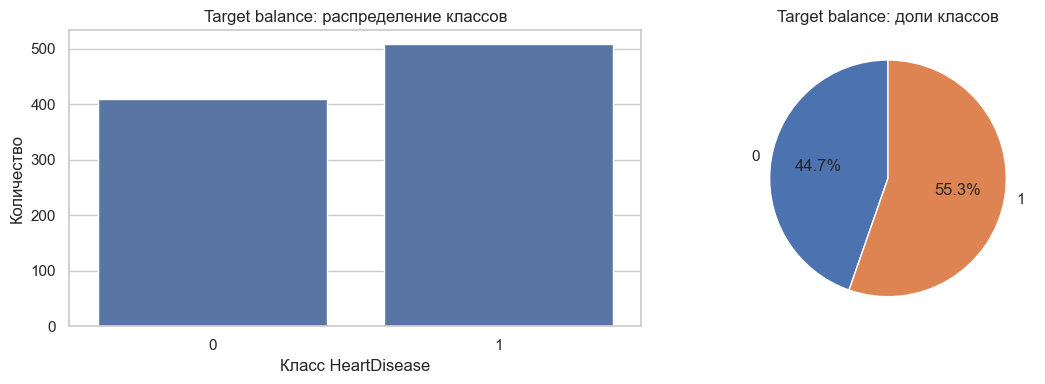

In [12]:
plot_target_balance(df)


## 5.2. Распределения категориальных признаков

In [13]:
def plot_categorical_overview(df: pd.DataFrame, categorical_cols: list[str]) -> None:
    """Строит обзор распределений по всем категориальным признакам.

    Parameters
    ----------
    df : pd.DataFrame
        Датасет, содержащий категориальные признаки.
    categorical_cols : list[str]
        Список названий категориальных столбцов для визуализации.

    Returns
    -------
    None
        Функция отображает набор столбчатых диаграмм.
    """
    n_cols = 2
    n_rows = int(np.ceil(len(categorical_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for idx, col in enumerate(categorical_cols):
        counts = df[col].value_counts(dropna=False)
        sns.barplot(
            x=counts.values,
            y=counts.index.astype(str),
            orient="h",
            color="#4C72B0",
            ax=axes[idx],
        )
        axes[idx].set_title(f"{col} (уникальных: {counts.shape[0]})")
        axes[idx].set_ylabel("")

    for idx in range(len(categorical_cols), len(axes)):
        fig.delaxes(axes[idx])

    fig.suptitle("Распределение категориальных признаков", fontsize=16)
    fig.supxlabel("Количество")
    plt.tight_layout(rect=(0.03, 0.03, 1, 0.98))
    plt.show()


### Обзор распределения категориальных признаков

График распределения значений по всем категориальным колонкам датасета.

График показывает структуру категориального пространства: преобладающие и редкие категории, а также потенциальную несбалансированность уровней признаков.

График необходим, потому что позволяет обосновать подход к кодированию категорий и заранее оценить риск смещения модели из-за редких уровней.

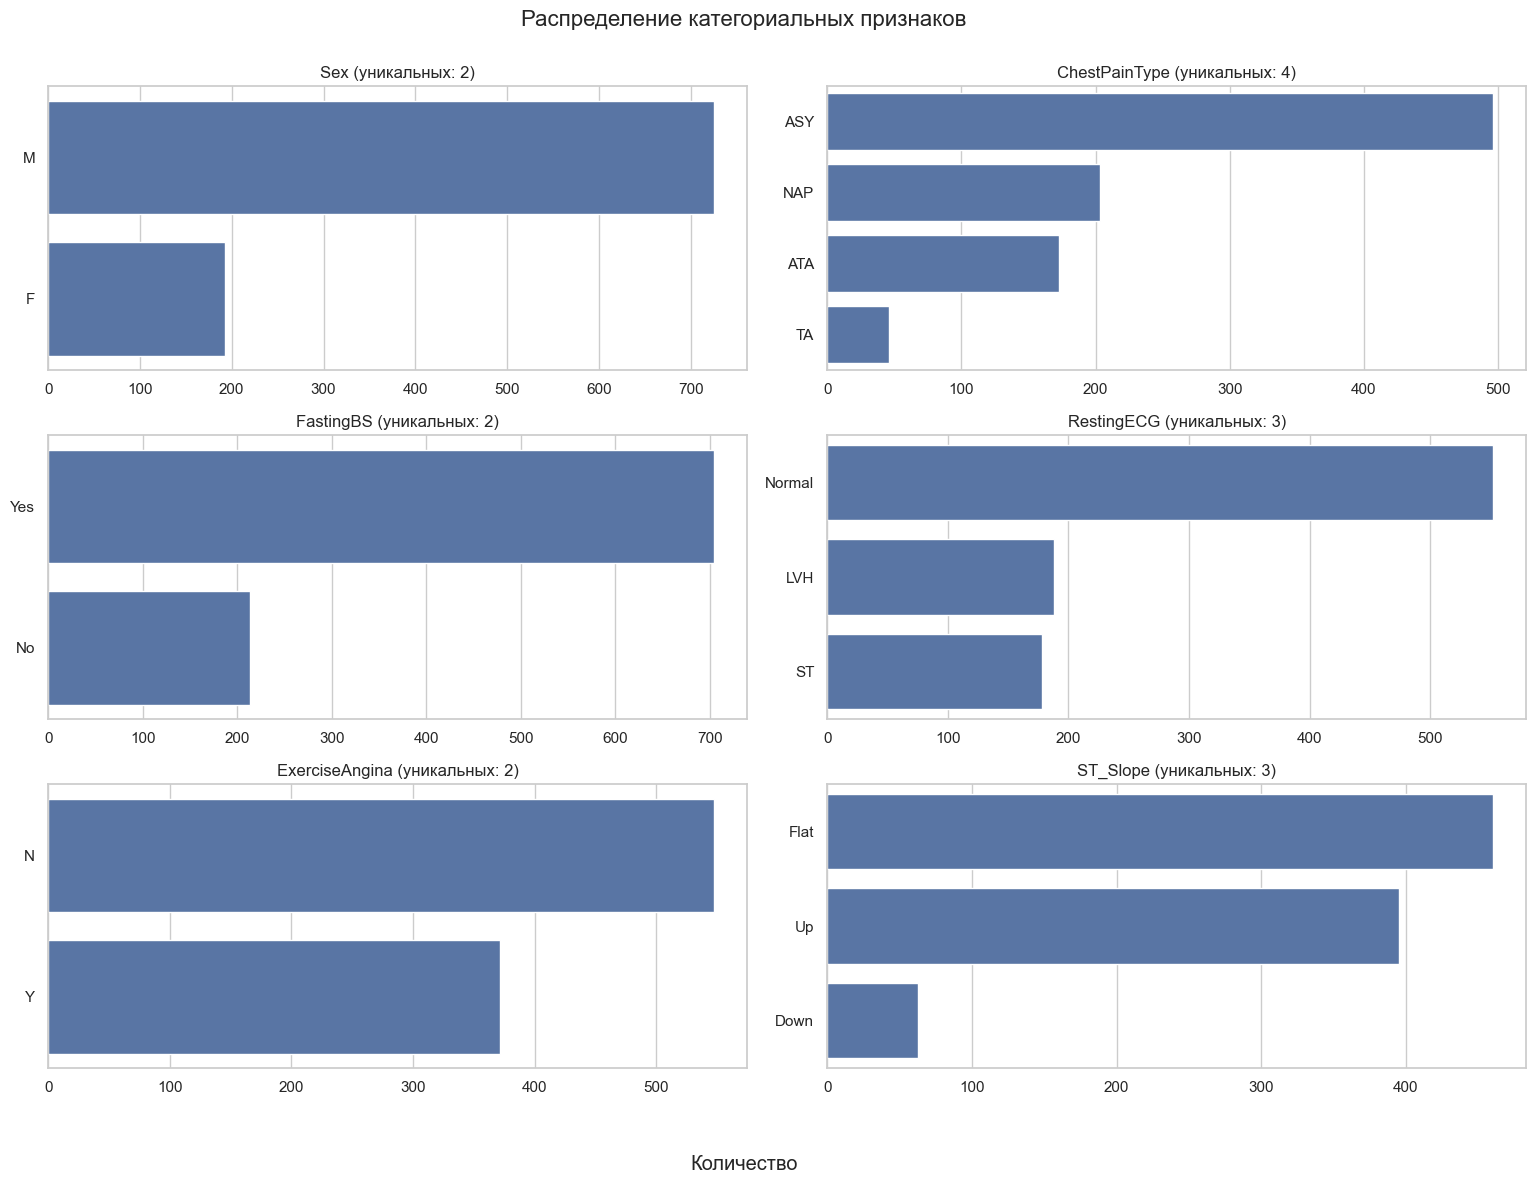

In [14]:
plot_categorical_overview(df, categorical_cols)


## 5.3. Conversion rate по категориальным признакам

In [15]:
def plot_categorical_conversion_rates(
    df: pd.DataFrame,
    categorical_cols: list[str],
    target_col: str = TARGET_COL,
) -> None:
    """Строит долю положительного класса для категориальных признаков.

    Parameters
    ----------
    df : pd.DataFrame
        Исходный датасет с признаками и целевой переменной.
    categorical_cols : list[str]
        Список категориальных признаков для анализа.
    target_col : str, default=TARGET_COL
        Название целевой переменной (`0`/`1`).

    Returns
    -------
    None
        Функция отображает набор горизонтальных barplot-графиков.
    """
    rate_df = df.copy()
    rate_df["target_positive"] = rate_df[target_col].astype(int)

    n_cols = 2
    n_rows = int(np.ceil(len(categorical_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for idx, col in enumerate(categorical_cols):
        rates = (
            rate_df.groupby(col, dropna=False)["target_positive"]
            .mean()
            .mul(100)
            .sort_values(ascending=False)
        )
        sns.barplot(
            x=rates.values,
            y=rates.index.astype(str),
            orient="h",
            color="#55A868",
            ax=axes[idx],
        )
        axes[idx].set_title(col)
        axes[idx].set_xlabel("")
        axes[idx].set_ylabel("")

    for idx in range(len(categorical_cols), len(axes)):
        fig.delaxes(axes[idx])

    fig.suptitle("Conversion rate по категориальным признакам", fontsize=16)
    fig.supxlabel("Доля класса HeartDisease=1, %")
    fig.supylabel("Категория")
    plt.tight_layout(rect=(0.03, 0.03, 1, 0.98))
    plt.show()


### Обзор conversion rate по категориальным признакам

График условной вероятности `P(HeartDisease=1)` для каждой категории каждого категориального признака.

График показывает, какие категории статистически ассоциированы с повышенной или пониженной вероятностью целевого события.

График необходим, потому что позволяет предварительно оценить дискриминирующую способность категориальных признаков и выделить наиболее информативные уровни.


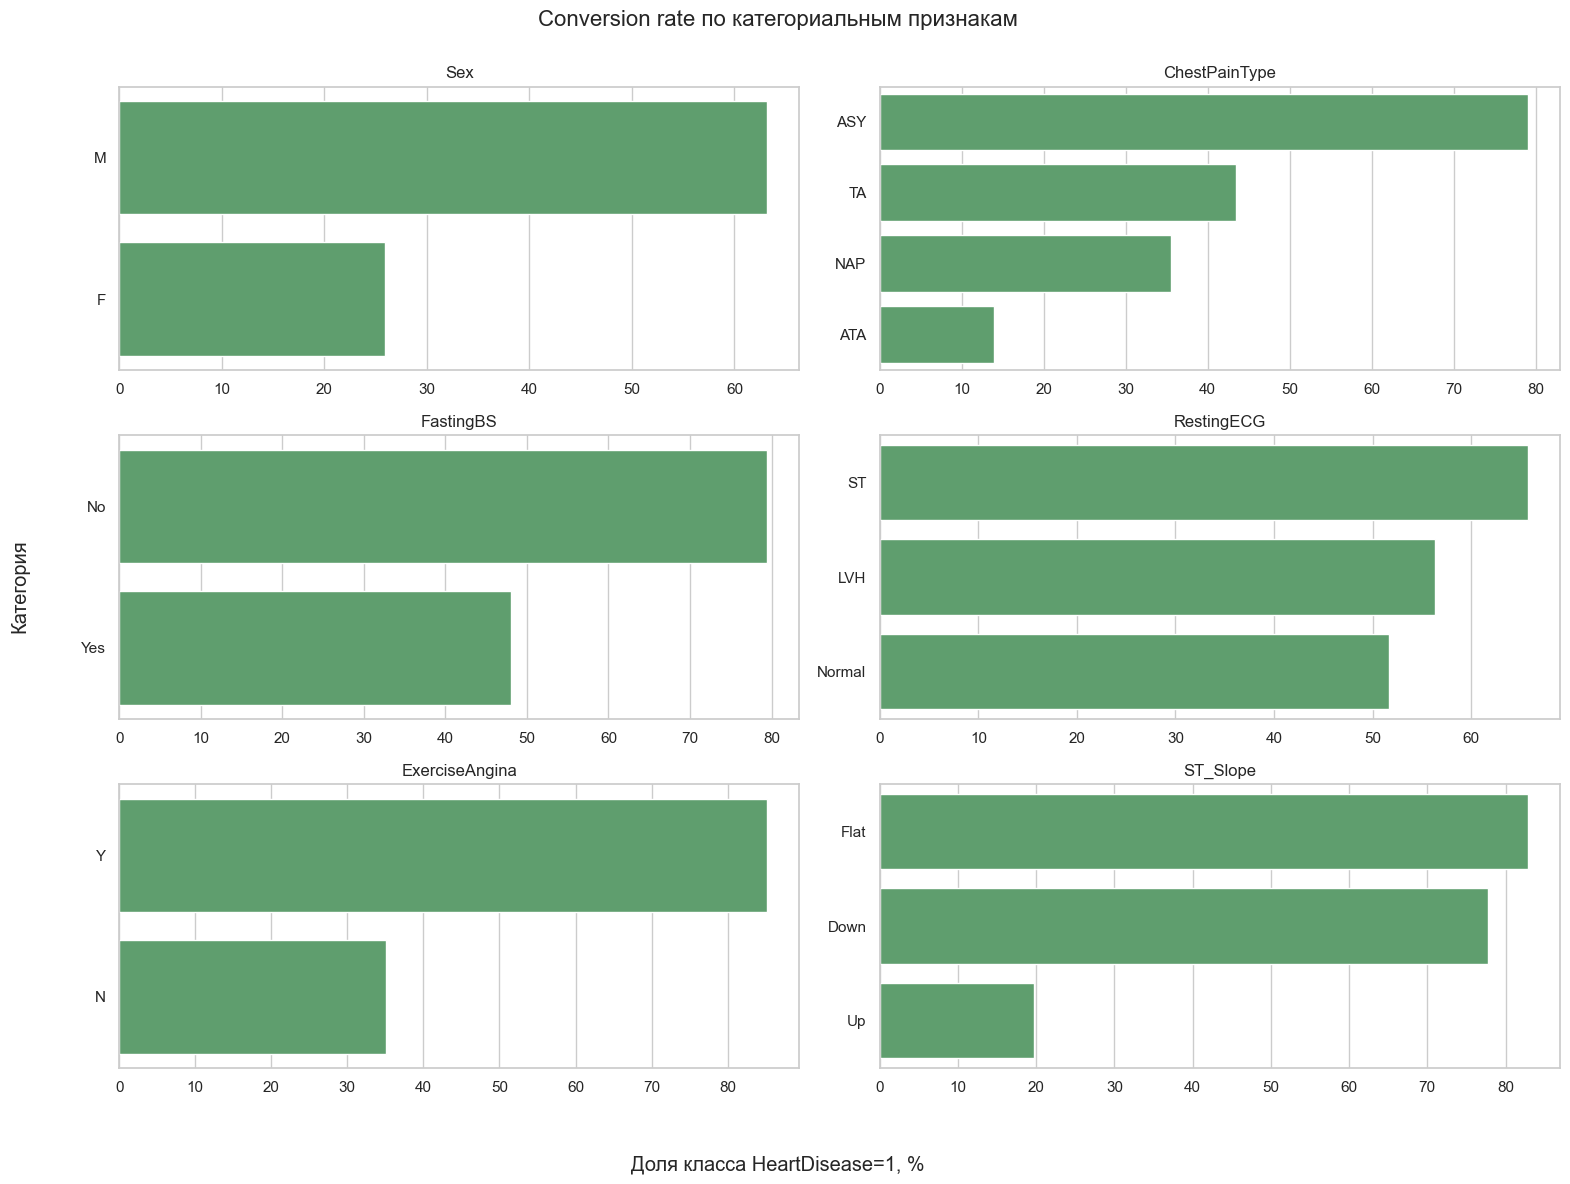

In [16]:
plot_categorical_conversion_rates(df, categorical_cols)


## 5.4. Распределения числовых признаков

In [17]:
def plot_numeric_distributions(df: pd.DataFrame, numeric_cols: list[str]) -> None:
    """Строит распределения всех числовых признаков.

    Parameters
    ----------
    df : pd.DataFrame
        Исходный датасет с числовыми столбцами.
    numeric_cols : list[str]
        Список числовых признаков для визуализации.

    Returns
    -------
    None
        Функция отображает набор гистограмм с KDE.
    """
    n_cols = 2
    n_rows = int(np.ceil(len(numeric_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for idx, col in enumerate(numeric_cols):
        sns.histplot(data=df, x=col, bins=30, kde=True, color="#4C72B0", ax=axes[idx])
        axes[idx].set_title(col)
        axes[idx].set_xlabel("")
        axes[idx].set_ylabel("")

    for idx in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[idx])

    fig.suptitle("Распределения числовых признаков", fontsize=16)
    fig.supylabel("Частота")
    plt.tight_layout(rect=(0.03, 0.03, 1, 0.98))
    plt.show()


### Обзор распределения числовых признаков

Графики одномерных распределений числовых переменных (гистограммы с оценкой плотности).

Графики показывают форму распределений признаков, наличие асимметрии, многомодальности и возможных выбросов.

Графики необходимы, потому что анализ распределений определяет корректность дальнейших преобразований признаков и повышает интерпретируемость результатов моделирования.

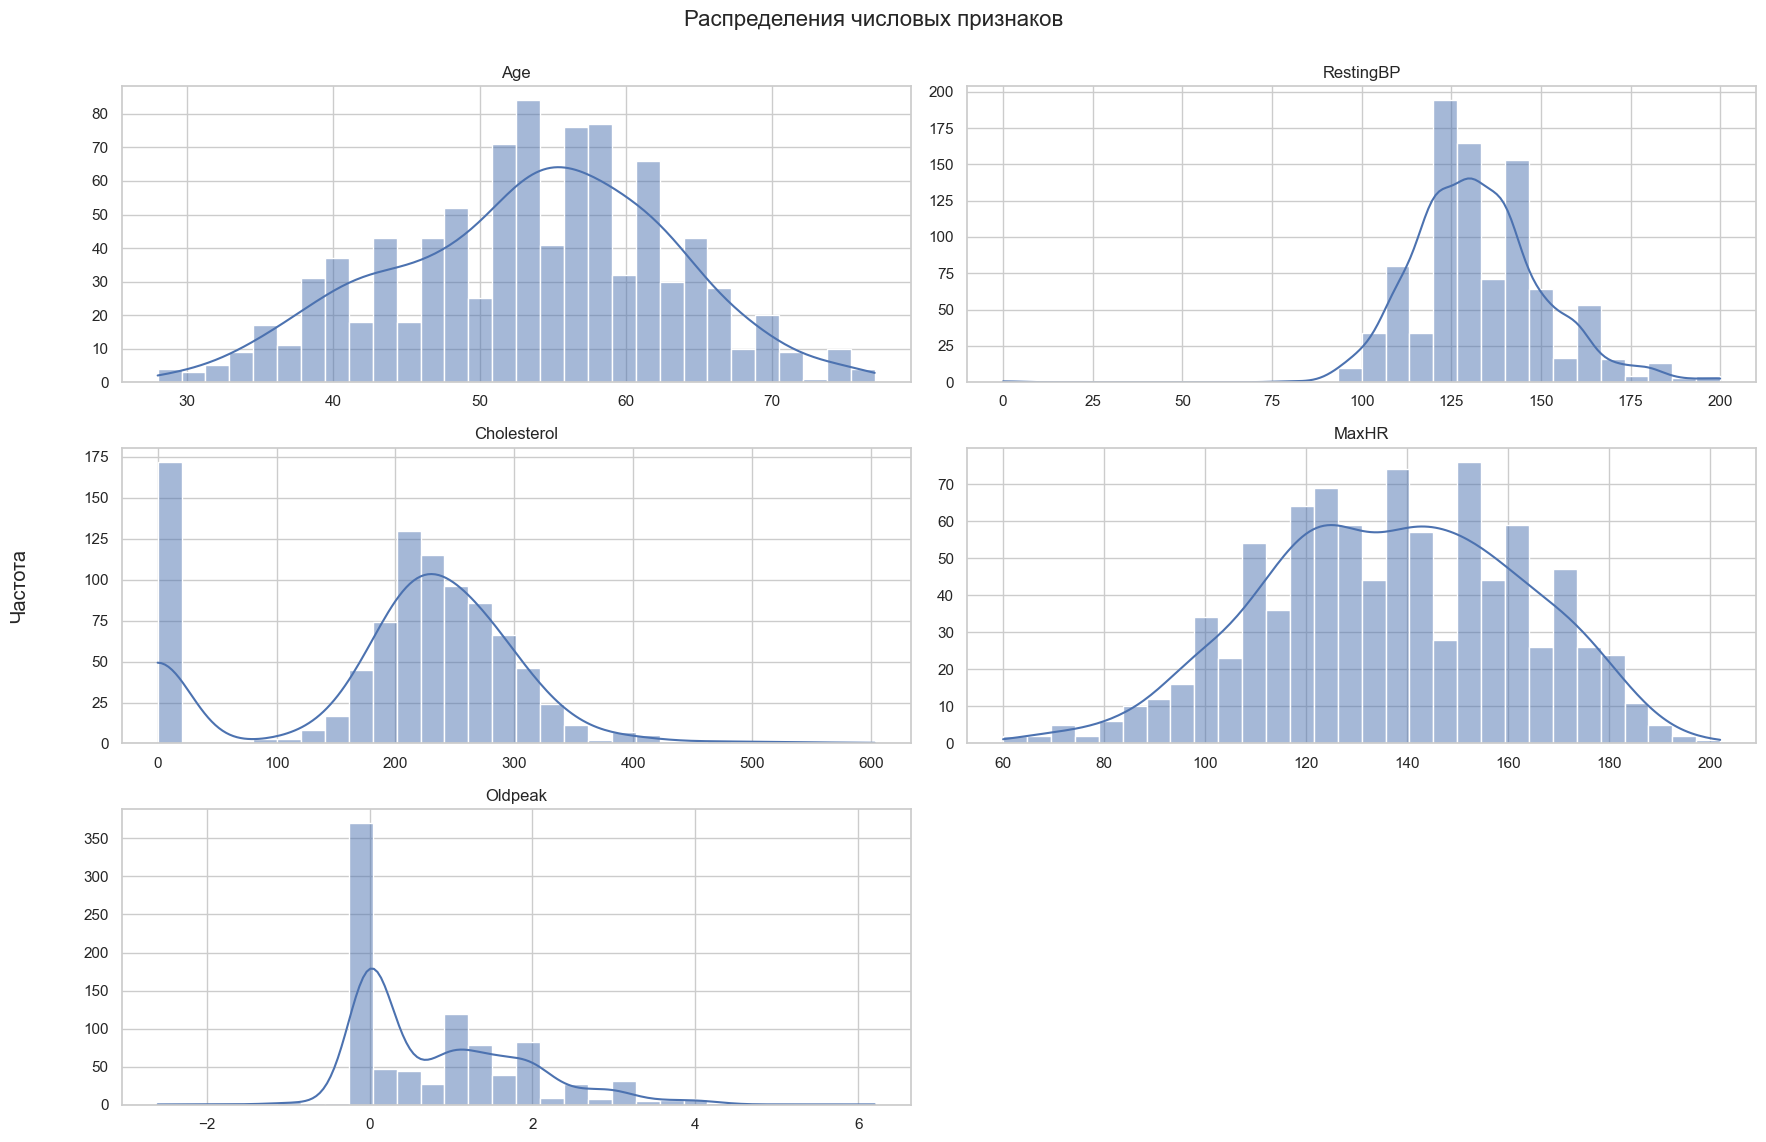

In [18]:
plot_numeric_distributions(df, numeric_cols)


## 5.5. Conversion rate по числовым признакам

In [19]:
def plot_numeric_binned_dependence(
    df: pd.DataFrame,
    numeric_cols: list[str],
    target_col: str = TARGET_COL,
    max_bins: int = 10,
) -> None:
    """Строит зависимость P(HeartDisease=1) от квантильных бинов числовых признаков.

    Parameters
    ----------
    df : pd.DataFrame
        Исходный датасет с признаками и целевой переменной.
    numeric_cols : list[str]
        Список числовых признаков, для которых строятся бины.
    target_col : str, default=TARGET_COL
        Название целевой переменной (`0`/`1`).
    max_bins : int, default=10
        Максимальное число квантильных интервалов для разбиения.

    Returns
    -------
    None
        Функция отображает набор линейных графиков по бинам.
    """
    binned_df = df.copy()
    binned_df["target_positive"] = binned_df[target_col].astype(int)

    n_cols = 2
    n_rows = int(np.ceil(len(numeric_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for idx, col in enumerate(numeric_cols):
        n_unique = binned_df[col].nunique(dropna=True)
        q = min(max_bins, int(n_unique))

        if q < 2:
            axes[idx].set_visible(False)
            continue

        bins = pd.qcut(binned_df[col], q=q, duplicates="drop")
        rates = (
            binned_df.groupby(bins, observed=False)["target_positive"]
            .mean()
            .mul(100)
        )

        x_values = np.arange(1, len(rates) + 1)
        sns.lineplot(x=x_values, y=rates.values, marker="o", color="#C44E52", ax=axes[idx])
        axes[idx].set_title(col)
        axes[idx].set_xlabel("")
        axes[idx].set_ylabel("")
        axes[idx].set_xticks(x_values)

    for idx in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[idx])

    fig.suptitle("Conversion rate по числовым признакам", fontsize=16)
    fig.supxlabel("Квантильный бин")
    fig.supylabel("P(HeartDisease=1), %")
    plt.tight_layout(rect=(0.03, 0.03, 1, 0.98))
    plt.show()


### Обзор conversion rate по числовым признакам (binned dependence)

Графики зависимости вероятности `P(HeartDisease=1)` от квантильных интервалов числовых признаков.

Графики показывают характер связи между значением признака и целевой переменной, включая возможные нелинейные эффекты.

Графики необходимы, потому что позволяют выявить закономерности, которые не фиксируются при анализе только линейной корреляции.


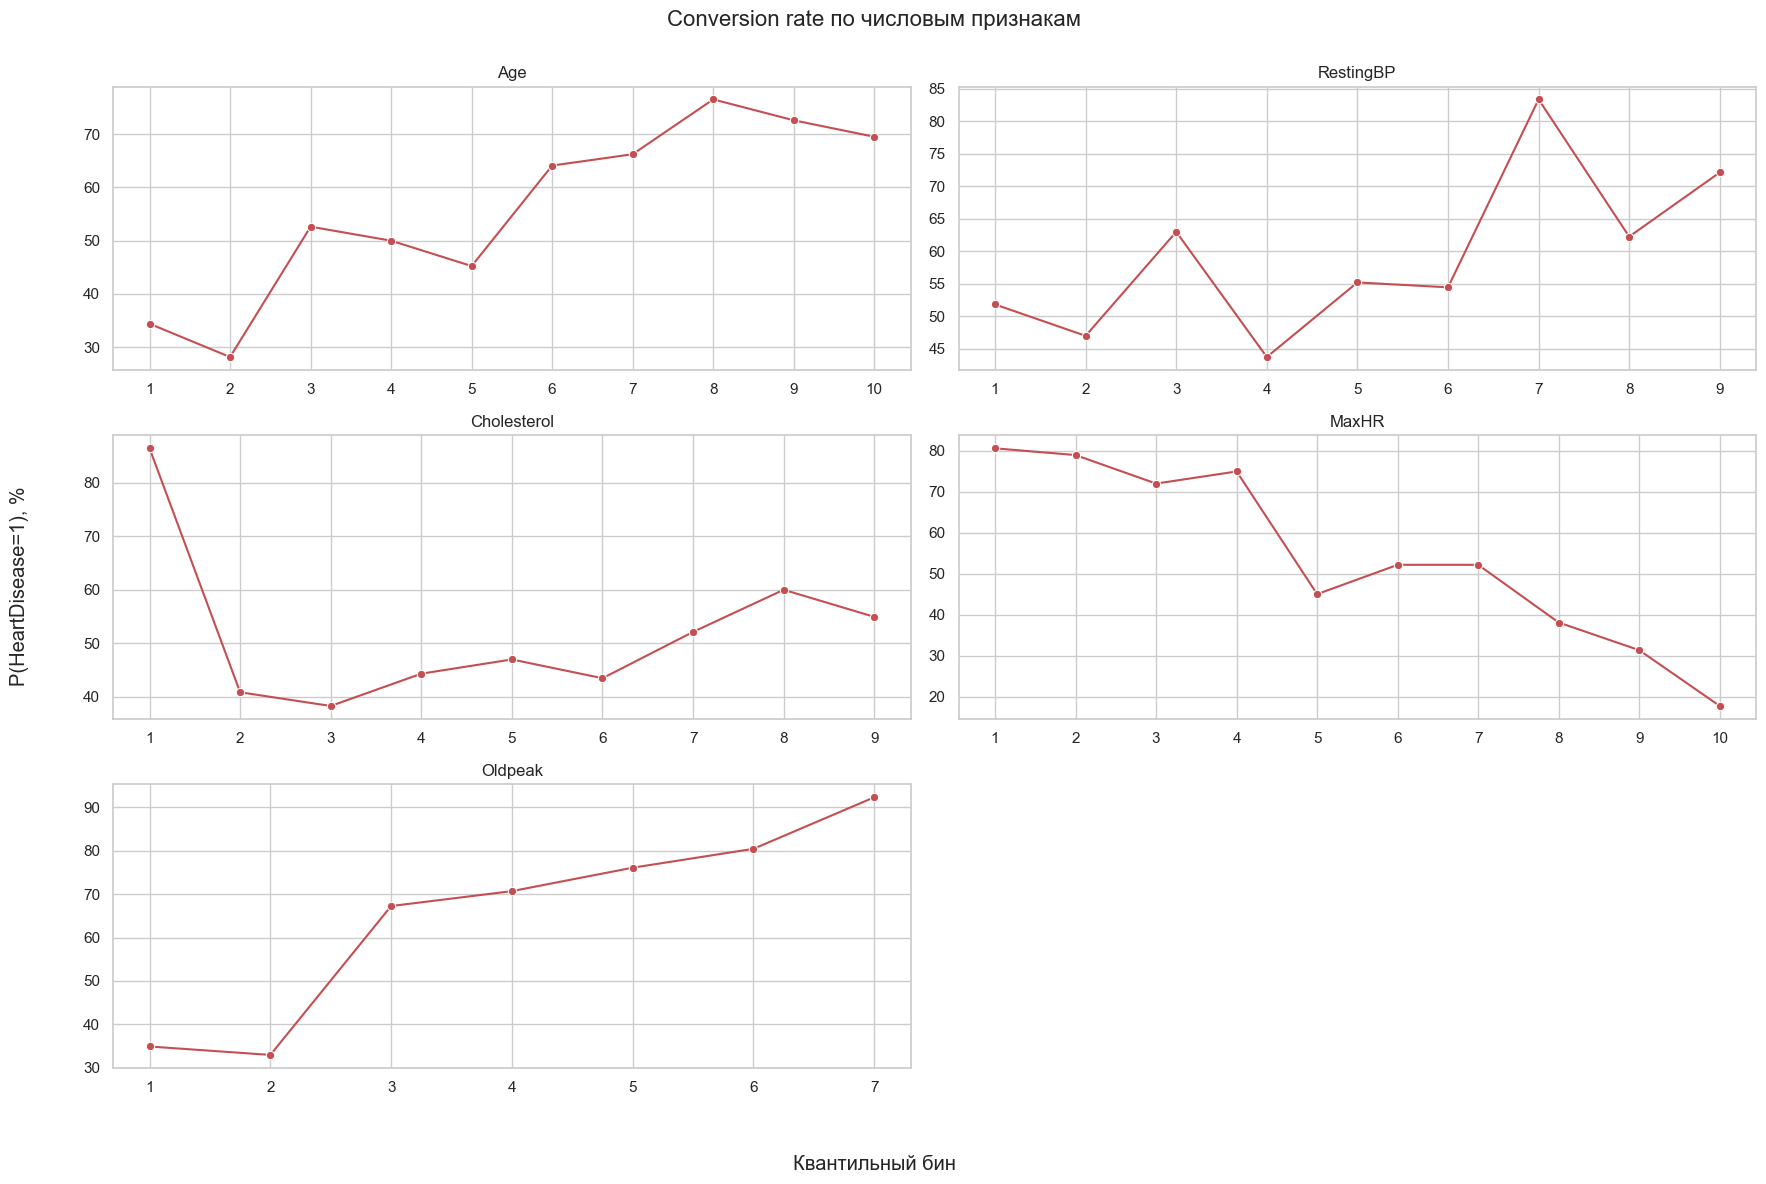

In [20]:
plot_numeric_binned_dependence(df, numeric_cols)


## 5.6. Корреляционная матрица числовых признаков

In [21]:
def plot_numeric_correlation_heatmap(df: pd.DataFrame, numeric_cols: list[str]) -> None:
    """Строит тепловую карту корреляций между числовыми признаками.

    Parameters
    ----------
    df : pd.DataFrame
        Исходный датасет с числовыми признаками.
    numeric_cols : list[str]
        Список числовых столбцов для расчета матрицы корреляций.

    Returns
    -------
    None
        Функция отображает heatmap-диаграмму коэффициентов корреляции.
    """
    corr = df[numeric_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Correlation heatmap числовых признаков")
    plt.tight_layout()
    plt.show()


### Обзор корреляционной матрицы числовых признаков

График тепловой карты попарных коэффициентов корреляции между числовыми признаками датасета.

График показывает направление и силу линейных связей между переменными, включая потенциально высоко коррелированные пары.

График необходим, потому что позволяет оценить мультиколлинеарность и корректно интерпретировать совместное влияние признаков при построении модели.

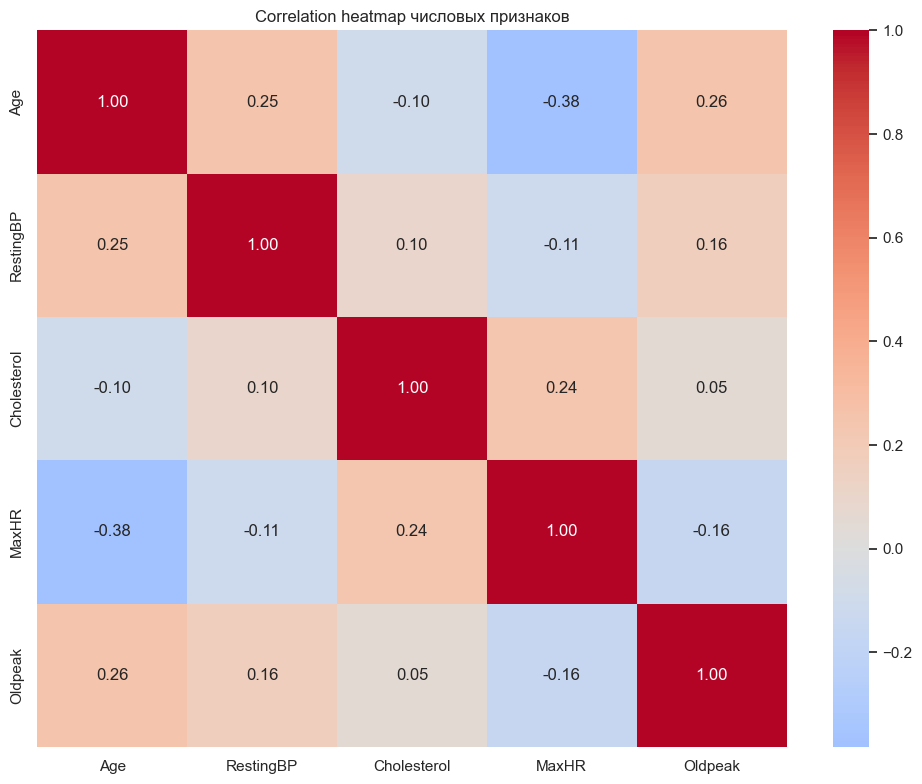

In [22]:
plot_numeric_correlation_heatmap(df, numeric_cols)


## 6. Вывод

По результатам EDA установлено, что целевая переменная `HeartDisease` имеет умеренно сбалансированное распределение классов, что позволяет корректно интерпретировать стандартные метрики бинарной классификации в сравнительном анализе моделей.

Категориальные и числовые признаки демонстрируют неоднородный вклад в вероятность сердечного заболевания: для части признаков наблюдаются выраженные различия между группами и нелинейные зависимости по квантильным интервалам.

Корреляционная структура числовых признаков указывает на наличие взаимосвязанных переменных, что необходимо учитывать при интерпретации результатов обучения и при выборе дальнейших методов классификации.
